# 01 — Exploratory Data Analysis (EDA)
## Detectia fraudelor financiare — Dataset CreditCard Fraud (ULB)

Acest notebook contine analiza exploratorie a datasetului **creditcard.csv**:
- Informatii de baza (shape, dtypes, valori nule, statistici descriptive)
- Distributia claselor (frauda vs legitima)
- Distributia Amount si Time
- Heatmap corelatie V1-V28
- Boxplot Amount frauda vs legitima

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurare stil grafice
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12

# Directorul pentru figuri
FIGURES_DIR = os.path.join('..', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Librarii incarcate cu succes.')

Librarii incarcate cu succes.


## 1. Incarcarea datelor si informatii de baza

In [2]:
# Incarcarea datasetului
df = pd.read_csv(os.path.join('..', 'data', 'creditcard.csv'))

print(f'Shape: {df.shape}')
print(f'Numar tranzactii: {df.shape[0]:,}')
print(f'Numar features: {df.shape[1]}')
print()
print('Primele 5 randuri:')
df.head()

Shape: (284807, 31)
Numar tranzactii: 284,807
Numar features: 31

Primele 5 randuri:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Tipuri de date
print('Tipuri de date:')
print(df.dtypes)
print()
print(f'Valori nule per coloana:')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'Nu exista valori nule.')

Tipuri de date:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Valori nule per coloana:
Nu exista valori nule.


In [4]:
# Statistici descriptive
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 2. Distributia claselor (Class Imbalance)

In [5]:
# Statistici clase
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print('Distributia claselor:')
print(f'  Legitime (0): {class_counts[0]:,} ({class_pct[0]:.3f}%)')
print(f'  Fraude  (1):  {class_counts[1]:,} ({class_pct[1]:.3f}%)')
print(f'  Ratio:        1:{class_counts[0] // class_counts[1]}')

Distributia claselor:
  Legitime (0): 284,315 (99.827%)
  Fraude  (1):  492 (0.173%)
  Ratio:        1:577


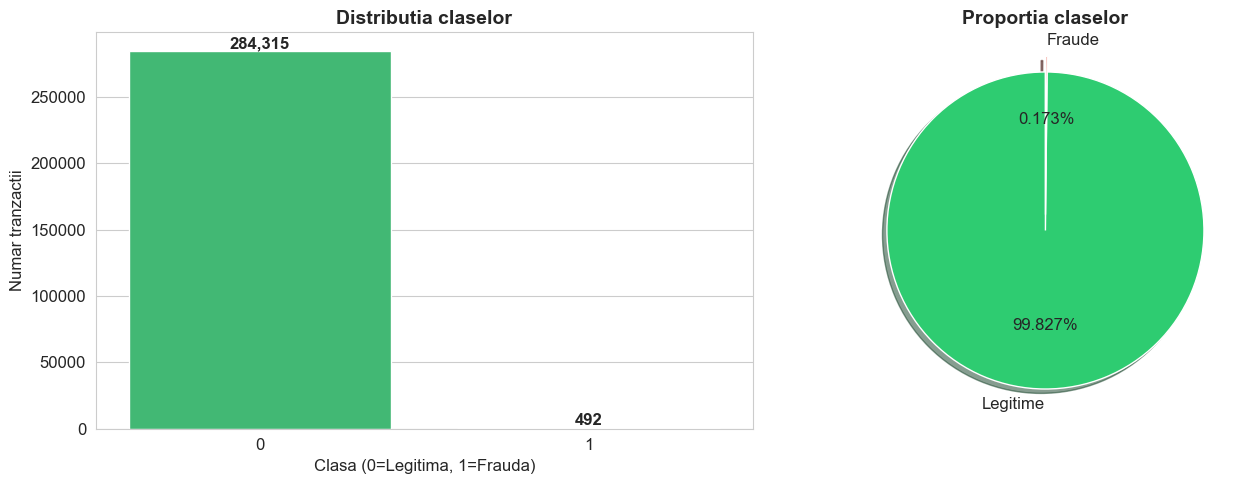

Salvat: figures/Figura_3_1.png


In [6]:
# Figura 3.1 — Countplot + Pie chart distributia claselor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
colors = ['#2ecc71', '#e74c3c']
sns.countplot(x='Class', data=df, ax=axes[0], palette=colors, hue='Class', legend=False)
axes[0].set_title('Distributia claselor', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clasa (0=Legitima, 1=Frauda)')
axes[0].set_ylabel('Numar tranzactii')
# Adaugam valorile pe bare
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=['Legitime', 'Fraude'],
    autopct='%1.3f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.1),
    shadow=True,
    textprops={'fontsize': 12}
)
axes[1].set_title('Proportia claselor', fontsize=14, fontweight='bold')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'Figura_3_1.png'), bbox_inches='tight')
plt.show()
print('Salvat: figures/Figura_3_1.png')

## 3. Distributia Amount si Time

In [7]:
# Separare fraude vs legitime
df_fraud = df[df['Class'] == 1]
df_legit = df[df['Class'] == 0]

print(f'Amount — Tranzactii legitime: mean={df_legit["Amount"].mean():.2f}, median={df_legit["Amount"].median():.2f}, max={df_legit["Amount"].max():.2f}')
print(f'Amount — Fraude:              mean={df_fraud["Amount"].mean():.2f}, median={df_fraud["Amount"].median():.2f}, max={df_fraud["Amount"].max():.2f}')

Amount — Tranzactii legitime: mean=88.29, median=22.00, max=25691.16
Amount — Fraude:              mean=122.21, median=9.25, max=2125.87


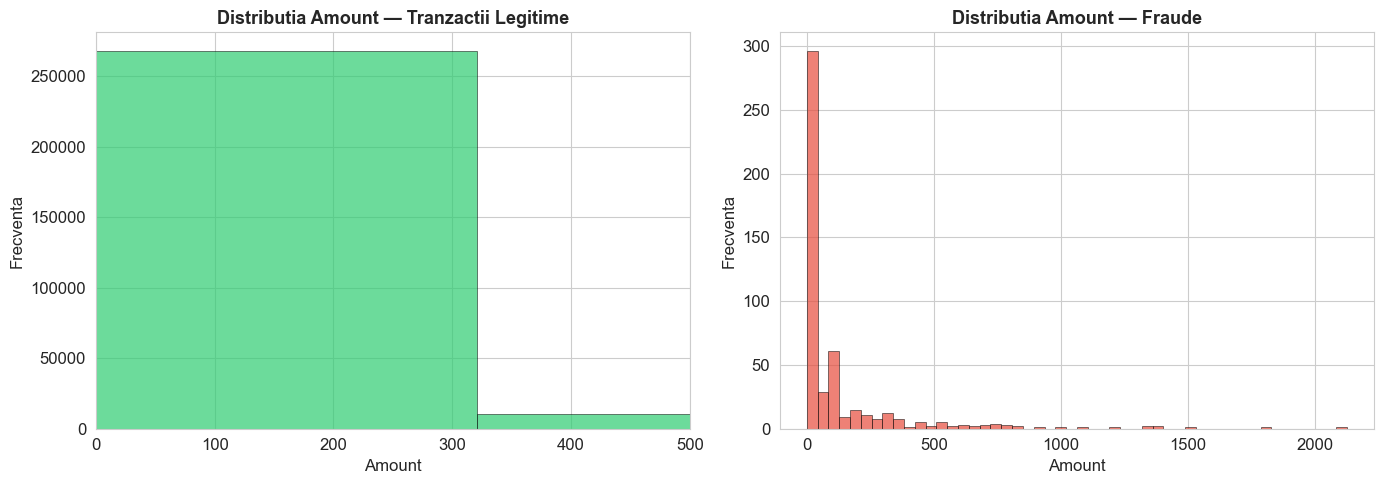

Salvat: figures/Figura_3_2.png


In [8]:
# Figura 3.2 — Distributia Amount (frauda vs legitima)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma Amount — legitime
axes[0].hist(df_legit['Amount'], bins=80, color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distributia Amount — Tranzactii Legitime', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frecventa')
axes[0].set_xlim(0, 500)  # zoom pe zona relevanta

# Histograma Amount — fraude
axes[1].hist(df_fraud['Amount'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].set_title('Distributia Amount — Fraude', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frecventa')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'Figura_3_2.png'), bbox_inches='tight')
plt.show()
print('Salvat: figures/Figura_3_2.png')

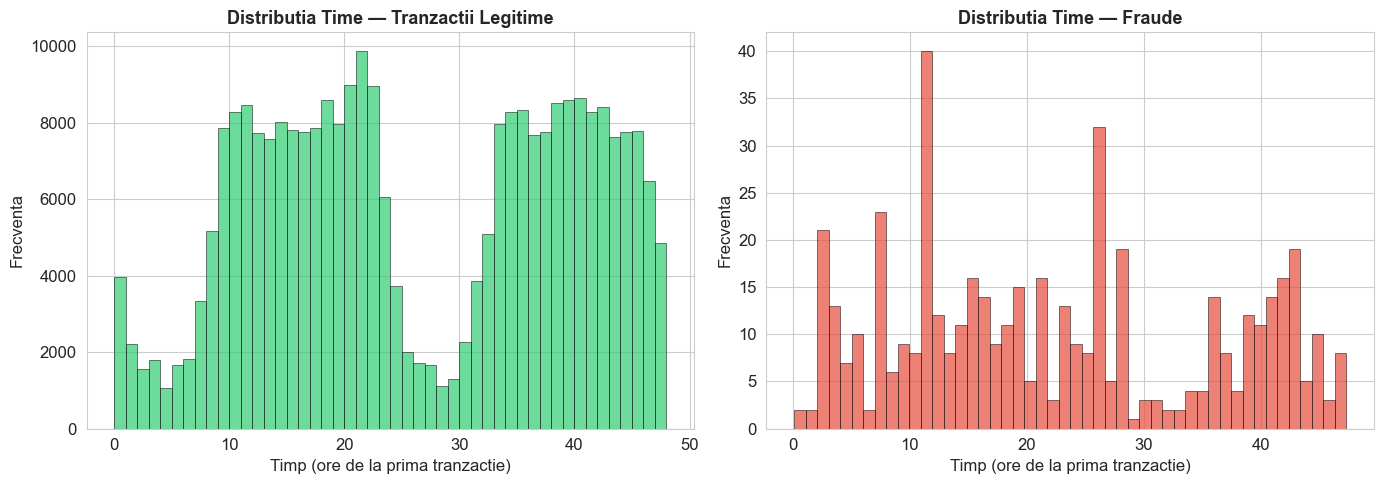

Salvat: figures/Figura_3_3.png


In [9]:
# Figura 3.3 — Distributia Time (frauda vs legitima)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convertim Time din secunde in ore
df['Time_hours'] = df['Time'] / 3600

# Histograma Time — legitime
axes[0].hist(df_legit['Time'] / 3600, bins=48, color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distributia Time — Tranzactii Legitime', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Timp (ore de la prima tranzactie)')
axes[0].set_ylabel('Frecventa')

# Histograma Time — fraude
axes[1].hist(df_fraud['Time'] / 3600, bins=48, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].set_title('Distributia Time — Fraude', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Timp (ore de la prima tranzactie)')
axes[1].set_ylabel('Frecventa')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'Figura_3_3.png'), bbox_inches='tight')
plt.show()
print('Salvat: figures/Figura_3_3.png')

## 4. Heatmap corelatie V1-V28

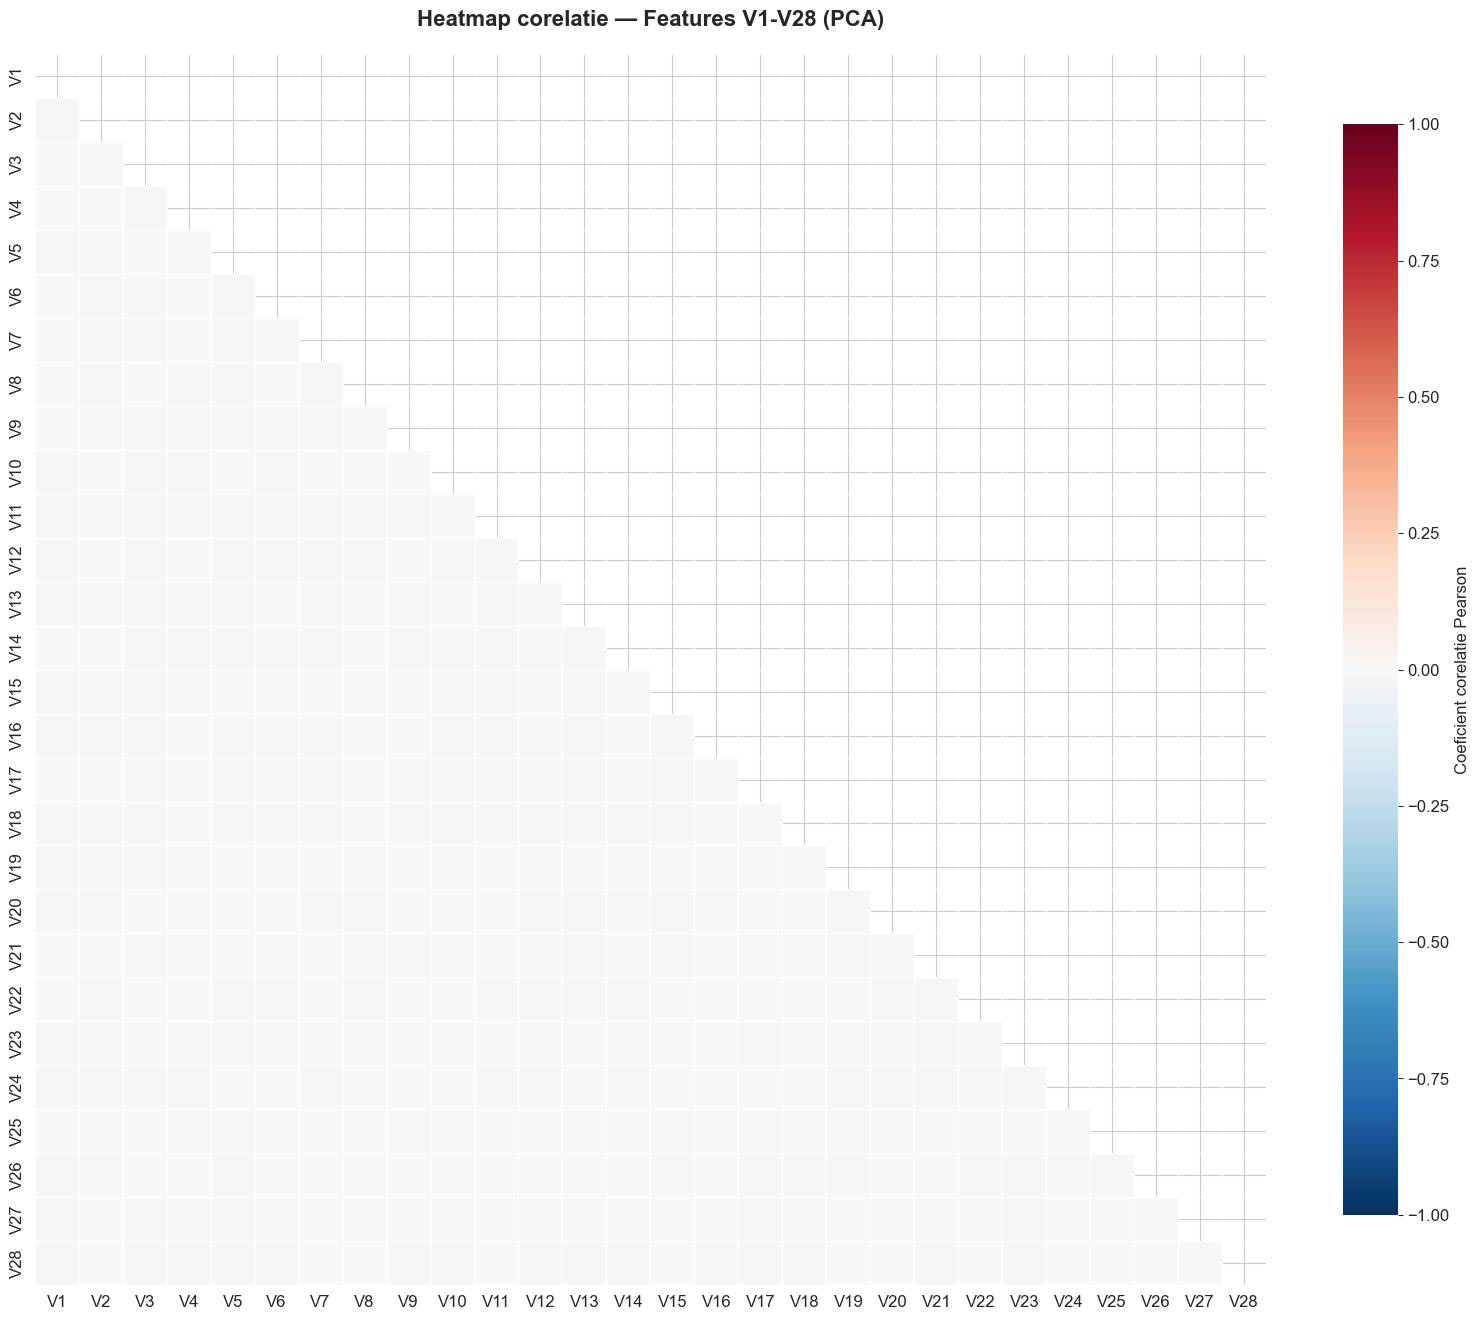

Salvat: figures/Figura_3_4.png


In [10]:
# Figura 3.4 — Heatmap corelatie features V1-V28
v_cols = [f'V{i}' for i in range(1, 29)]
corr_matrix = df[v_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # masca pentru triunghiul superior

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot=False,
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Coeficient corelatie Pearson'}
)
ax.set_title('Heatmap corelatie — Features V1-V28 (PCA)', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'Figura_3_4.png'), bbox_inches='tight')
plt.show()
print('Salvat: figures/Figura_3_4.png')

## 5. Boxplot Amount — Frauda vs Legitima

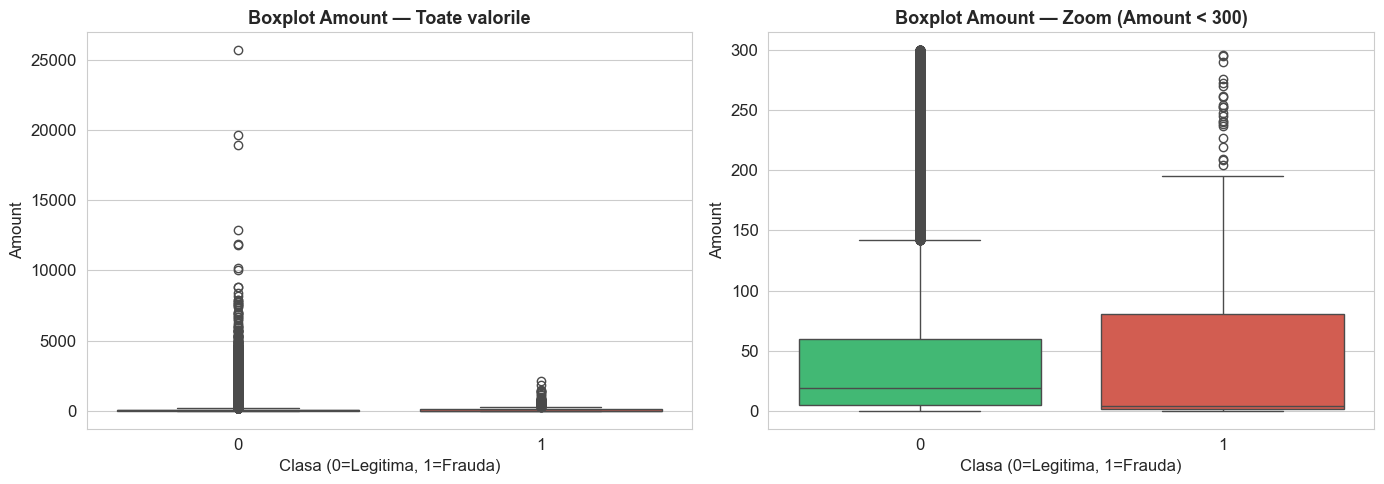

Salvat: figures/Figura_3_5.png


In [11]:
# Figura 3.5 — Boxplot Amount frauda vs legitima
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot complet
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], palette=colors, hue='Class', legend=False)
axes[0].set_title('Boxplot Amount — Toate valorile', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clasa (0=Legitima, 1=Frauda)')
axes[0].set_ylabel('Amount')

# Boxplot zoom (Amount < 300 pentru vizibilitate)
sns.boxplot(x='Class', y='Amount', data=df[df['Amount'] < 300], ax=axes[1], palette=colors, hue='Class', legend=False)
axes[1].set_title('Boxplot Amount — Zoom (Amount < 300)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Clasa (0=Legitima, 1=Frauda)')
axes[1].set_ylabel('Amount')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'Figura_3_5.png'), bbox_inches='tight')
plt.show()
print('Salvat: figures/Figura_3_5.png')

## SUMMARY

In [12]:
# Statistici cheie — celula SUMMARY
print('=' * 60)
print('SUMMARY — EDA CreditCard Fraud Dataset')
print('=' * 60)
print(f'Total tranzactii:          {len(df):,}')
print(f'Tranzactii legitime:       {len(df_legit):,} ({len(df_legit)/len(df)*100:.3f}%)')
print(f'Tranzactii frauda:         {len(df_fraud):,} ({len(df_fraud)/len(df)*100:.3f}%)')
print(f'Ratio frauda/legitime:     1:{len(df_legit)//len(df_fraud)}')
print(f'Features:                  V1-V28 (PCA) + Amount + Time')
print(f'Valori nule:               {df.isnull().sum().sum()}')
print('-' * 60)
print(f'Amount mediu — legitime:   {df_legit["Amount"].mean():.2f}')
print(f'Amount mediu — fraude:     {df_fraud["Amount"].mean():.2f}')
print(f'Amount median — legitime:  {df_legit["Amount"].median():.2f}')
print(f'Amount median — fraude:    {df_fraud["Amount"].median():.2f}')
print(f'Amount max — legitime:     {df_legit["Amount"].max():.2f}')
print(f'Amount max — fraude:       {df_fraud["Amount"].max():.2f}')
print('-' * 60)
print(f'Perioada acoperita:        {df["Time"].max()/3600:.1f} ore')
print('=' * 60)
print()
print('Figuri generate:')
print('  Figura_3_1.png — Distributia claselor (countplot + pie)')
print('  Figura_3_2.png — Distributia Amount (frauda vs legitima)')
print('  Figura_3_3.png — Distributia Time (frauda vs legitima)')
print('  Figura_3_4.png — Heatmap corelatie V1-V28')
print('  Figura_3_5.png — Boxplot Amount (frauda vs legitima)')

SUMMARY — EDA CreditCard Fraud Dataset
Total tranzactii:          284,807
Tranzactii legitime:       284,315 (99.827%)
Tranzactii frauda:         492 (0.173%)
Ratio frauda/legitime:     1:577
Features:                  V1-V28 (PCA) + Amount + Time
Valori nule:               0
------------------------------------------------------------
Amount mediu — legitime:   88.29
Amount mediu — fraude:     122.21
Amount median — legitime:  22.00
Amount median — fraude:    9.25
Amount max — legitime:     25691.16
Amount max — fraude:       2125.87
------------------------------------------------------------
Perioada acoperita:        48.0 ore

Figuri generate:
  Figura_3_1.png — Distributia claselor (countplot + pie)
  Figura_3_2.png — Distributia Amount (frauda vs legitima)
  Figura_3_3.png — Distributia Time (frauda vs legitima)
  Figura_3_4.png — Heatmap corelatie V1-V28
  Figura_3_5.png — Boxplot Amount (frauda vs legitima)
